# Model 11: Naïve Bayes Classifier

### Objective
Naïve Bayes uses pure probability (Bayes' Theorem) to predict the attendance band. It assumes every feature is completely independent of the others (e.g., that 'Rainy' has nothing to do with 'Morning'), which is 'naïve' but often highly effective.

In [1]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('evidence', exist_ok=True)

### 1. Load Datasets & Encode Targets

In [2]:
X_train = pd.read_csv('../../../../../data/processed/X_train_scaled.csv')
y_train_raw = pd.read_csv('../../../../../data/processed/y_train_class.csv').squeeze()

X_val = pd.read_csv('../../../../../data/processed/X_val_scaled.csv')
y_val_raw = pd.read_csv('../../../../../data/processed/y_val_class.csv').squeeze()

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_val = le.transform(y_val_raw)

print("Classes:", le.classes_)
print("Datasets loaded successfully.")

Classes: ['High' 'Low' 'Medium']
Datasets loaded successfully.


### 2. Model Training

In [3]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("✅ Naïve Bayes Classifier Trained Successfully.")

✅ Naïve Bayes Classifier Trained Successfully.


### 3. Classification Evaluation

In [4]:
def evaluate_classification(model, X, y_true, model_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    try:
        y_prob = model.predict_proba(X)
        roc = roc_auc_score(y_true, y_prob, multi_class='ovr')
    except AttributeError:
        roc = np.nan
        
    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    if not np.isnan(roc):
        print(f"ROC-AUC:  {roc:.4f}\n")
    else:
        print("ROC-AUC:  N/A\n")
        
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    return y_pred, acc, f1, roc

print("========== TRAINING SET ==========")
_, train_acc, train_f1, train_roc = evaluate_classification(nb_model, X_train, y_train, "11_naive_bayes (TRAIN)")

print("========== VALIDATION SET ==========")
val_preds, val_acc, val_f1, val_roc = evaluate_classification(nb_model, X_val, y_val, "11_naive_bayes (VAL)")

========== TRAINING SET ==========
--- 11_naive_bayes (TRAIN) ---
Accuracy: 0.4571
F1 Score: 0.4372
ROC-AUC:  0.6552

              precision    recall  f1-score   support

        High       0.41      0.80      0.54       105
         Low       0.54      0.38      0.45       124
      Medium       0.52      0.24      0.33       121

    accuracy                           0.46       350
   macro avg       0.49      0.47      0.44       350
weighted avg       0.49      0.46      0.43       350

========== VALIDATION SET ==========
--- 11_naive_bayes (VAL) ---
Accuracy: 0.4133
F1 Score: 0.4116
ROC-AUC:  0.5663

              precision    recall  f1-score   support

        High       0.28      0.94      0.43        16
         Low       0.67      0.33      0.44        24
      Medium       0.80      0.23      0.36        35

    accuracy                           0.41        75
   macro avg       0.58      0.50      0.41        75
weighted avg       0.65      0.41      0.40        75



### 4. Confusion Matrix

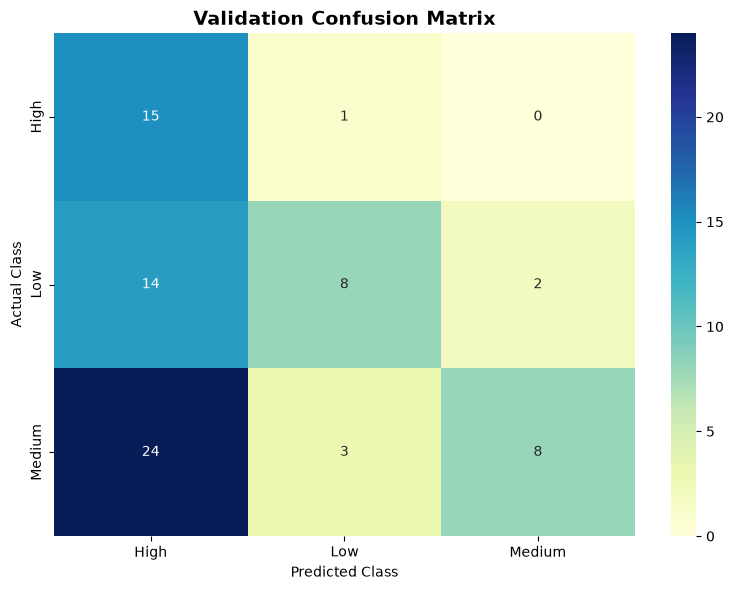

In [5]:
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Validation Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.savefig('evidence/01_nb_confusion_matrix.png', dpi=300)
plt.show()

### Experiment Tracking
Automatically append the metrics of this model to our global `experiment_results.csv` matrix for the final deliverable.

In [6]:
import datetime
import os

tracker_file = '../../../../../data/processed/experiment_results.csv'
file_exists = os.path.isfile(tracker_file)

experiment_data = pd.DataFrame({
    'Timestamp': [datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
    'Model_ID': ['11_naive_bayes'],
    'Model_Type': ['Classification'],
    'Val_MAE': [np.nan],
    'Val_RMSE': [np.nan],
    'Val_MAPE': [np.nan],
    'Val_R2': [np.nan],
    'Val_Accuracy': [val_acc],
    'Val_F1': [val_f1],
    'Val_ROCAUC': [val_roc]
})

experiment_data.to_csv(tracker_file, mode='a', header=not file_exists, index=False)
print(f"✅ Experiment logged successfully to {tracker_file}")

✅ Experiment logged successfully to ../../../../../data/processed/experiment_results.csv
